# Clustering jerárquico sobre embeddings AE

Notebook de prueba para sustituir temporalmente el GMM por clustering jerárquico aglomerativo y generar una visualización de resultados por clúster similar a los reportes actuales.

## Qué hace
- Carga embeddings latentes del autoencoder para `training`, `validation` y `test`.
- Ajusta un `AgglomerativeClustering` solo sobre `training`.
- Deriva prototipos por clúster en el espacio latente.
- Asigna `validation` y `test` al clúster más cercano por centróides.
- Reordena y renombra clústeres según riesgo académico usando `final_result`.
- Genera un gráfico conjunto con la misma idea visual que `clustering_outcomes_all_splits.png`.

## Nota metodológica
El clustering jerárquico no dispone de `predict` nativo para datos fuera de muestra. Para poder comparar `training`, `validation` y `test`, este notebook usa una extensión pragmática: asignar cada embedding al centróide jerárquico más cercano aprendido en `training`.

In [8]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

ROOT = Path('/workspace/TFM_education_ai_analytics')
EMBEDDINGS_DIR = ROOT / 'data' / '4_embeddings'
FEATURES_DIR = ROOT / 'data' / '3_features'
OUT_DIR = ROOT / 'reports' / 'clustering_hierarchical_test'
OUT_DIR.mkdir(parents=True, exist_ok=True)

WINDOW = 5
N_CLUSTERS = 5
LINKAGE = 'ward'
USE_STANDARDIZED_LATENT = True
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
print({'WINDOW': WINDOW, 'N_CLUSTERS': N_CLUSTERS, 'LINKAGE': LINKAGE, 'OUT_DIR': str(OUT_DIR)})

{'WINDOW': 5, 'N_CLUSTERS': 5, 'LINKAGE': 'ward', 'OUT_DIR': '/workspace/TFM_education_ai_analytics/reports/clustering_hierarchical_test'}


In [9]:
def load_latent(split: str, window: int) -> pd.DataFrame:
    path = EMBEDDINGS_DIR / split / f'upto_w{int(window):02d}' / 'ae_latent.csv'
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, index_col=0).sort_index()


def load_target(split: str) -> pd.DataFrame:
    path = FEATURES_DIR / split / 'target.csv'
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, index_col=0).sort_index()


def nearest_centroid_assign(x: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    diff = x[:, None, :] - centroids[None, :, :]
    dist2 = np.sum(diff * diff, axis=2)
    return np.argmin(dist2, axis=1).astype(int)


def compute_cluster_stats(cluster_ids: np.ndarray, target_df: pd.DataFrame) -> pd.DataFrame:
    df = pd.DataFrame({'cluster_id': cluster_ids}, index=target_df.index).join(target_df[['final_result']], how='inner')
    df['is_withdrawn'] = (df['final_result'] == 0).astype(int)
    df['is_success'] = df['final_result'].isin([2, 3]).astype(int)

    stats = (
        df.groupby('cluster_id')
        .agg(
            n=('cluster_id', 'size'),
            withdrawn_rate=('is_withdrawn', 'mean'),
            success_rate=('is_success', 'mean'),
        )
        .reset_index()
    )
    stats['withdrawn_pct'] = stats['withdrawn_rate'] * 100.0
    stats['success_pct'] = stats['success_rate'] * 100.0
    return stats


def build_rank_mapping(stats: pd.DataFrame) -> dict:
    ordered = stats.sort_values(['withdrawn_rate', 'success_rate'], ascending=[False, True]).reset_index(drop=True)
    label_pack = [
        ('CRITICAL_RISK_INACTIVE', 'Riesgo critico (inactivos)'),
        ('STANDARD_PROFILE', 'Perfil intermedio A'),
        ('METHODICAL_EXPLORER', 'Perfil intermedio B'),
        ('CONSISTENT_GOOD', 'Perfil intermedio C'),
        ('STRATEGIC_HIGH_PERFORMER', 'Alto rendimiento (estrategico)'),
    ]

    mapping = {}
    for rank, row in ordered.iterrows():
        label, name = label_pack[min(rank, len(label_pack) - 1)]
        mapping[int(row['cluster_id'])] = {
            'rank': int(rank),
            'label': label,
            'name': name,
            'n': int(row['n']),
            'withdrawn_pct': float(row['withdrawn_pct']),
            'success_pct': float(row['success_pct']),
        }
    return mapping


ID2NAME = {0: 'Withdrawn', 1: 'Fail', 2: 'Pass', 3: 'Distinction'}
PLOT_ORDER = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
BAR_CFG = [
    ('Distinction', 'Excelencia (Distinction)', '#3DDC97'),
    ('Pass', 'Aprobado (Pass)', '#64B5F6'),
    ('Fail', 'Suspenso (Fail)', '#FFB74D'),
    ('Withdrawn', 'Abandono (Withdrawn)', '#EF5350'),
]
CLUSTER_TICK_COLORS = ['#1E88E5', '#FB8C00', '#43A047', '#E53935', '#8E24AA', '#00897B']

In [10]:
train_latent = load_latent('training', WINDOW)
val_latent = load_latent('validation', WINDOW)
test_latent = load_latent('test', WINDOW)

train_target = load_target('training')
val_target = load_target('validation')
test_target = load_target('test')

common_train = train_latent.index.intersection(train_target.index)
common_val = val_latent.index.intersection(val_target.index)
common_test = test_latent.index.intersection(test_target.index)

train_latent = train_latent.loc[common_train]
val_latent = val_latent.loc[common_val]
test_latent = test_latent.loc[common_test]

train_target = train_target.loc[common_train]
val_target = val_target.loc[common_val]
test_target = test_target.loc[common_test]

scaler = StandardScaler()
x_train = train_latent.to_numpy(dtype=np.float32)
x_val = val_latent.to_numpy(dtype=np.float32)
x_test = test_latent.to_numpy(dtype=np.float32)

if USE_STANDARDIZED_LATENT:
    x_train_fit = scaler.fit_transform(x_train)
    x_val_fit = scaler.transform(x_val)
    x_test_fit = scaler.transform(x_test)
else:
    x_train_fit = x_train
    x_val_fit = x_val
    x_test_fit = x_test

hc = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage=LINKAGE)
train_cluster_ids = hc.fit_predict(x_train_fit).astype(int)

centroids = np.vstack([x_train_fit[train_cluster_ids == cluster_id].mean(axis=0) for cluster_id in range(N_CLUSTERS)])
val_cluster_ids = nearest_centroid_assign(x_val_fit, centroids)
test_cluster_ids = nearest_centroid_assign(x_test_fit, centroids)

train_stats = compute_cluster_stats(train_cluster_ids, train_target)
cluster_mapping = build_rank_mapping(train_stats)

train_sil = silhouette_score(x_train_fit, train_cluster_ids) if len(np.unique(train_cluster_ids)) > 1 else np.nan
train_db = davies_bouldin_score(x_train_fit, train_cluster_ids) if len(np.unique(train_cluster_ids)) > 1 else np.nan

print('Train silhouette:', round(float(train_sil), 4))
print('Train Davies-Bouldin:', round(float(train_db), 4))
pd.DataFrame.from_dict(cluster_mapping, orient='index').sort_values('rank')

Train silhouette: 0.1532
Train Davies-Bouldin: 1.9143


,rank,label,name,n,withdrawn_pct,success_pct
3,0,CRITICAL_RISK_INACTIVE,Riesgo critico (inactivos),3205,81.809672,3.619345
2,1,STANDARD_PROFILE,Perfil intermedio A,2648,54.720544,14.539275
4,2,METHODICAL_EXPLORER,Perfil intermedio B,3971,22.991690,44.069504
0,3,CONSISTENT_GOOD,Perfil intermedio C,11184,16.550429,65.414878
1,4,STRATEGIC_HIGH_PERFORMER,Alto rendimiento (estrategico),1777,15.194147,65.559932


In [11]:
def build_segmentation_frame(index: pd.Index, cluster_ids: np.ndarray, mapping: dict) -> pd.DataFrame:
    df = pd.DataFrame({'cluster_id': cluster_ids}, index=index)
    df['cluster_name'] = df['cluster_id'].map(lambda cid: mapping[int(cid)]['name'])
    df['cluster_rank'] = df['cluster_id'].map(lambda cid: mapping[int(cid)]['rank'])
    df['cluster_label'] = df['cluster_id'].map(lambda cid: mapping[int(cid)]['label'])
    return df.sort_values(['cluster_rank', 'cluster_id'])


seg_train = build_segmentation_frame(train_latent.index, train_cluster_ids, cluster_mapping)
seg_val = build_segmentation_frame(val_latent.index, val_cluster_ids, cluster_mapping)
seg_test = build_segmentation_frame(test_latent.index, test_cluster_ids, cluster_mapping)

SEG_DIR = OUT_DIR / f'week_{WINDOW:02d}'
SEG_DIR.mkdir(parents=True, exist_ok=True)
seg_train.to_csv(SEG_DIR / 'segmentation_hierarchical_training.csv')
seg_val.to_csv(SEG_DIR / 'segmentation_hierarchical_validation.csv')
seg_test.to_csv(SEG_DIR / 'segmentation_hierarchical_test.csv')

with open(SEG_DIR / 'hierarchical_cluster_mapping.json', 'w', encoding='utf-8') as f:
    json.dump({str(k): v for k, v in cluster_mapping.items()}, f, indent=2, ensure_ascii=False)

SEG_DIR

PosixPath('/workspace/TFM_education_ai_analytics/reports/clustering_hierarchical_test/week_05')

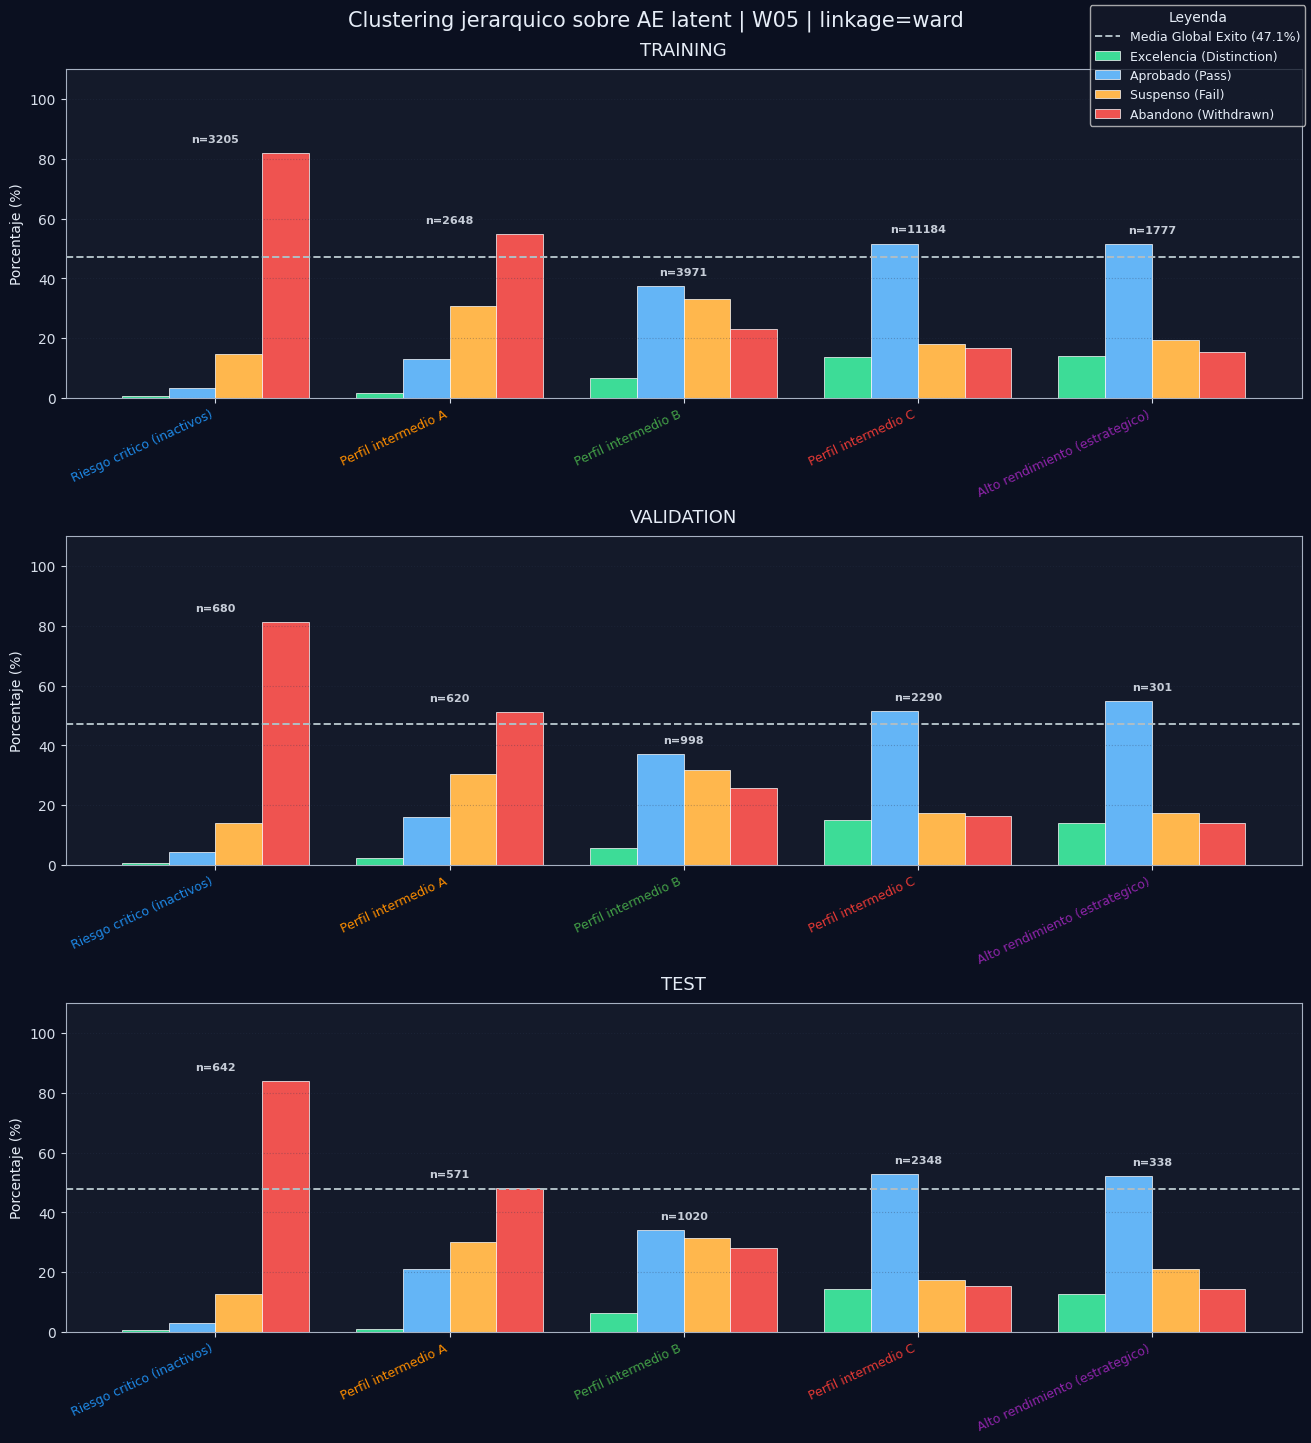

/workspace/TFM_education_ai_analytics/reports/clustering_hierarchical_test/week_05/clustering_outcomes_hierarchical_all_splits.png


In [12]:
def compute_outcome_table(seg_df: pd.DataFrame, target_df: pd.DataFrame):
    df_tgt = target_df[['final_result']].copy()
    df_tgt['actual_result_name'] = df_tgt['final_result'].map(ID2NAME).fillna('Withdrawn')
    df_tgt['is_success'] = df_tgt['final_result'].isin([2, 3]).astype(int)

    df = seg_df.join(df_tgt, how='inner')
    tab = pd.crosstab(df['cluster_name'], df['actual_result_name'], normalize='index') * 100.0
    for col in PLOT_ORDER:
        if col not in tab.columns:
            tab[col] = 0.0
    tab = tab[PLOT_ORDER]

    stats = df.groupby('cluster_name').agg(n=('cluster_id', 'size'), rank=('cluster_rank', 'first'))
    tab = tab.join(stats).sort_values('rank')
    global_success = float(df['is_success'].mean() * 100.0)
    return tab, global_success


def apply_dark_theme():
    plt.style.use('dark_background')
    plt.rcParams.update({
        'figure.facecolor': '#0B1020',
        'axes.facecolor': '#141A2A',
        'savefig.facecolor': '#0B1020',
        'axes.edgecolor': '#A7B1C2',
        'axes.labelcolor': '#E6EDF7',
        'text.color': '#E6EDF7',
        'xtick.color': '#D7DEEA',
        'ytick.color': '#D7DEEA',
        'grid.color': '#2A3550',
        'font.size': 10,
    })


def plot_outcome_panel(ax, tab: pd.DataFrame, global_success: float, title_str: str):
    x = np.arange(len(tab))
    width = 0.20
    offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

    for i, (col, label, color) in enumerate(BAR_CFG):
        ax.bar(x + offsets[i], tab[col].values, width=width, label=label, color=color, edgecolor='white', linewidth=0.5)

    ax.axhline(global_success, color='#B0BEC5', linestyle='--', linewidth=1.4, label=f'Media Global Exito ({global_success:.1f}%)')
    ax.set_title(title_str, fontsize=13, pad=10)
    ax.set_ylabel('Porcentaje (%)')
    ax.set_ylim(0, 110)
    ax.set_xticks(x)
    ax.set_xticklabels(tab.index.values, rotation=25, ha='right', fontsize=9)
    ax.grid(True, axis='y', alpha=0.30, linestyle=':')

    for i, tick in enumerate(ax.get_xticklabels()):
        tick.set_color(CLUSTER_TICK_COLORS[i % len(CLUSTER_TICK_COLORS)])

    for i, n_i in enumerate(tab['n'].values):
        y_max = float(max(tab.iloc[i][col] for col in PLOT_ORDER))
        ax.text(i, y_max + 3, f'n={int(n_i)}', ha='center', va='bottom', fontsize=8, fontweight='bold', alpha=0.85)


tabs = {
    'TRAINING': compute_outcome_table(seg_train, train_target),
    'VALIDATION': compute_outcome_table(seg_val, val_target),
    'TEST': compute_outcome_table(seg_test, test_target),
}

apply_dark_theme()
fig, axes = plt.subplots(3, 1, figsize=(13, 14), constrained_layout=True)
for ax, (split_name, (tab, global_success)) in zip(axes, tabs.items()):
    plot_outcome_panel(ax, tab, global_success, split_name)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', frameon=True, fontsize=9, title='Leyenda')
fig.suptitle(f'Clustering jerarquico sobre AE latent | W{WINDOW:02d} | linkage={LINKAGE}', fontsize=15, y=1.02)

plot_path = SEG_DIR / 'clustering_outcomes_hierarchical_all_splits.png'
plt.savefig(plot_path, dpi=220, bbox_inches='tight')
plt.show()
print(plot_path)

In [13]:
summary_rows = []
for split_name, seg_df, target_df in [
    ('training', seg_train, train_target),
    ('validation', seg_val, val_target),
    ('test', seg_test, test_target),
]:
    tab, global_success = compute_outcome_table(seg_df, target_df)
    summary_rows.append({
        'split': split_name,
        'global_success_pct': global_success,
        'n_students': int(tab['n'].sum()),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SEG_DIR / 'hierarchical_summary.csv', index=False)
summary_df

,split,global_success_pct,n_students
0,training,47.101163,22785
1,validation,47.023931,4889
2,test,47.855255,4919


## Siguientes pruebas sugeridas
- Cambiar `WINDOW` para comparar semanas tempranas y tardías.
- Probar `N_CLUSTERS = 6` si quieres contrastar con el JSON legacy que a veces usa 6 grupos.
- Comparar `LINKAGE = 'ward'`, `'complete'` y `'average'` sobre el mismo `WINDOW`.
- Contrastar esta salida frente al GMM usando `silhouette`, `davies_bouldin` y estabilidad de los perfiles pedagógicos.